In [555]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [556]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import normalizeDataFrame, fillNaNs, one_hot_encoding
from src.data_Splitting import divideDataFrame, cross_validation_mse
from src.models import LinearRegression
from src.metrics import errors,rmse,plot_error_histogram

EJERCICIO 1

In [557]:
df_raw = pd.read_csv("data/raw/casas_dev.csv")  

print(df_raw.head())  # Muestra las primeras 5 filas

     area area_units  is_house  has_pool   age  price        lat        lon  \
0   635.0       sqft         1         0  18.0  546.0  40.679064 -74.007844   
1  1098.0       sqft         0         0   9.0  759.0  40.712839 -73.967750   
2   667.0       sqft         0         0   7.0  464.0  40.669863 -74.029414   
3   127.0         m2         1         1  16.0  251.0 -34.600437 -58.415266   
4  1378.0       sqft         0         0   8.0  963.0  40.722322 -73.983229   

   rooms  
0    2.0  
1    3.0  
2    2.0  
3    4.0  
4    4.0  


Es posible ver como la columna de area_units puede omitirse realizando cierta transformacion para que todas las areas de las casas esten en las mismas unidades. 1 pie cuadrado equivale a aproximadamente 0.092903 metros cuadrados. Creamos un nuevo dataset para poder procesar y limpiar los datos sin modificar el el dataset original.Una vez transformadas las unidades, podemos borrar esa columna. Ademas, con respecto a los NaNs, podemos lidiar con estos valores de dos formas distintas. Podemos eliminar directamente toda la muestra o podemos reemplazar el valor con la media de la columna.

In [558]:
df_proccesed = df_raw.copy()

df_proccesed.loc[df_proccesed["area_units"] == "sqft", "area"] = 0.092903 * df_proccesed["area"]

df_proccesed=df_proccesed.drop(columns=["area_units"])

df_proccesed = fillNaNs(df_proccesed)




In [559]:
df_proccesed.head()  # Muestra las primeras 5 filas

,area,is_house,has_pool,age,price,lat,lon,rooms
0,58.993405,1,0,18.0,546.0,40.679064,-74.007844,2.0
1,102.007494,0,0,9.0,759.0,40.712839,-73.967750,3.0
2,61.966301,0,0,7.0,464.0,40.669863,-74.029414,2.0
3,127.000000,1,1,16.0,251.0,-34.600437,-58.415266,4.0
4,128.020334,0,0,8.0,963.0,40.722322,-73.983229,4.0


In [560]:
df_proccesed.info()
df_proccesed.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      900 non-null    float64
 1   is_house  900 non-null    int64  
 2   has_pool  900 non-null    int64  
 3   age       900 non-null    float64
 4   price     900 non-null    float64
 5   lat       900 non-null    float64
 6   lon       900 non-null    float64
 7   rooms     900 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 56.4 KB


,area,is_house,has_pool,age,price,lat,lon,rooms
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,94.794747,0.418889,0.144444,10.326667,466.197778,1.966225,-65.967203,2.758889
std,30.220560,0.493651,0.351735,4.423112,347.122903,37.661269,7.813671,0.912574
min,40.000000,0.000000,0.000000,1.000000,65.000000,-34.686302,-74.058238,1.000000
25%,74.000000,0.000000,0.000000,7.000000,178.750000,-34.605803,-74.005566,2.000000
50%,92.995903,0.000000,0.000000,11.000000,323.500000,-34.529704,-58.459293,3.000000
75%,111.264314,1.000000,0.000000,13.000000,712.500000,40.709819,-58.379873,3.000000
max,237.000000,1.000000,1.000000,20.000000,1992.000000,40.764550,-58.295919,5.000000


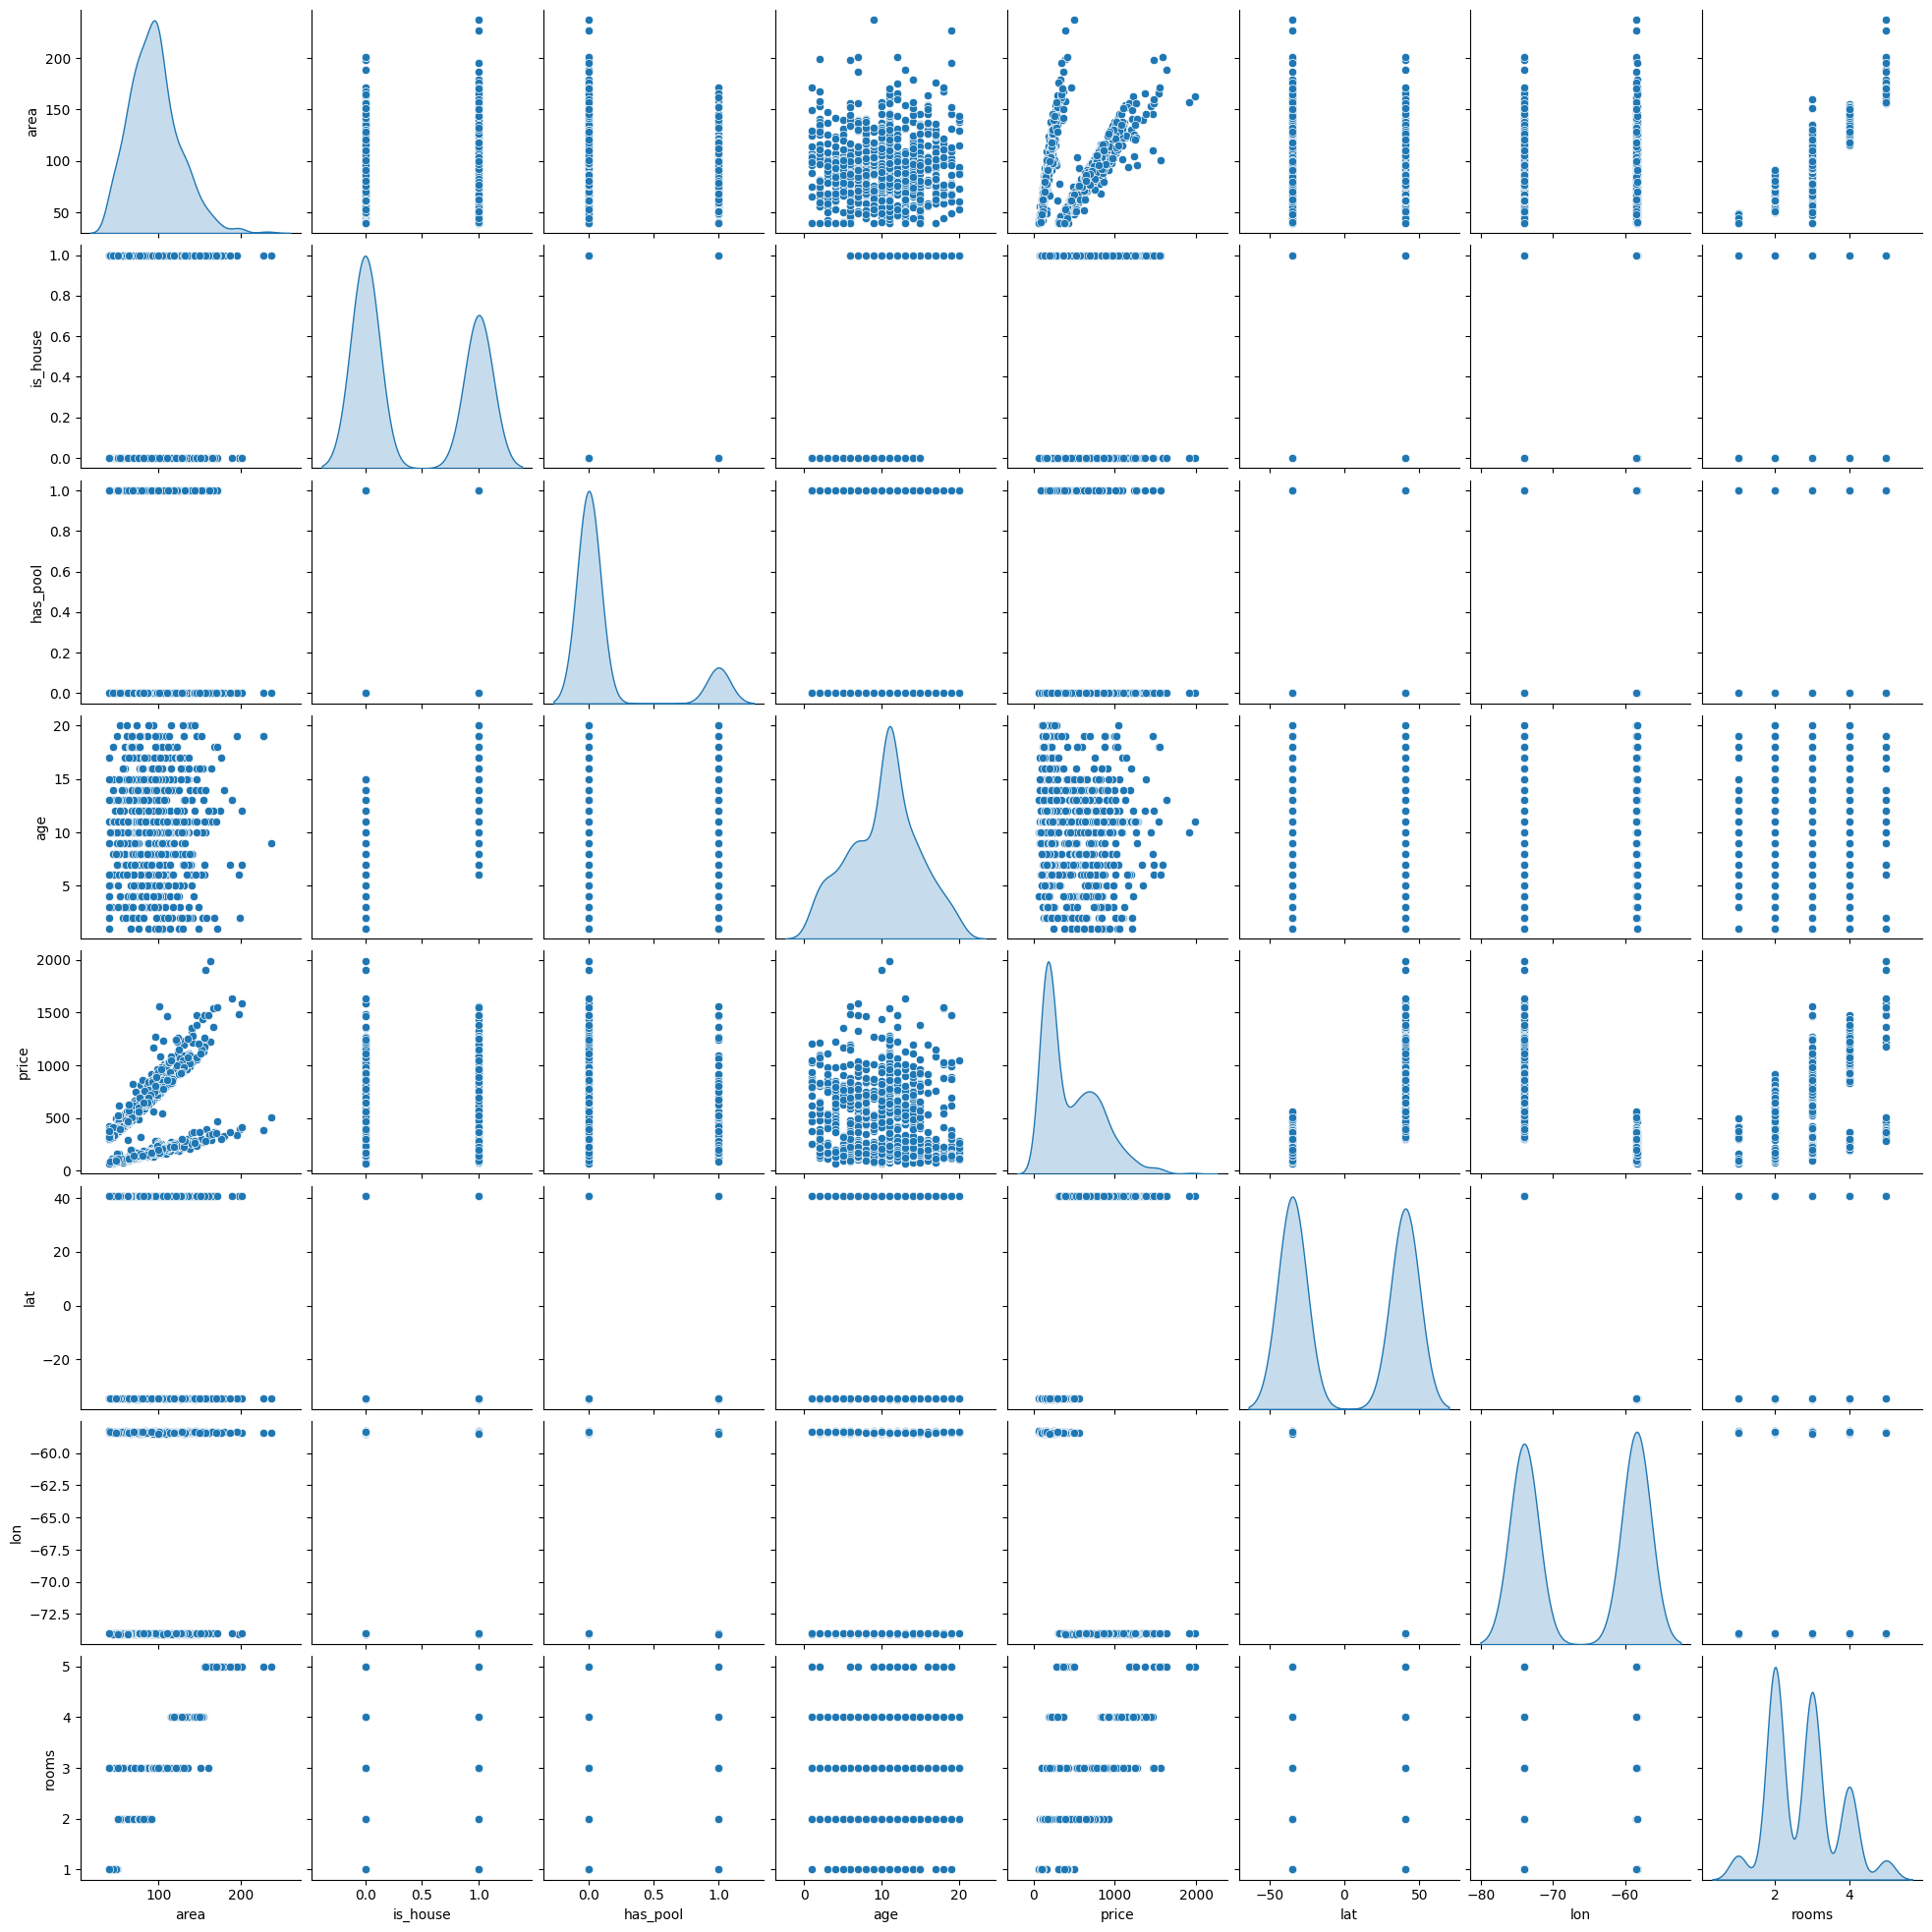

In [561]:
sns.pairplot(df_proccesed,diag_kind="kde")
plt.show()

A simple vista es posible relacionar el area con el precio. se aprecia que a medida que el area aumenta, el precio tambien lo hace. algo similar ocurre con la cantidad de cuartos. Analizando los datos de las ubicaciones de la casas,(lat y lon) se llego a la conclusion de que las casas se encuentran solo en dos localidades, la cual en una de ellas el precio de las casas aumenta mas rapido cuando el area aumenta.

Dado que las casas se encuentran solo en dos ubicaciones, podriamos modificar nuevamente el dataset para hacer one hot encoding. Las nuevas categorias serian zona 1 y zona 2. Gracias al pairplot, podemos predecir que las dos zonas estaran ubicadas en (-40,-50) y (40,-70) 


In [562]:
lat1, lon1 = -40, -50  
lat2, lon2 = 40, -70  

dist_zona1 = np.sqrt((df_proccesed["lat"] - lat1)**2 + (df_proccesed["lon"] - lon1)**2)
dist_zona2 = np.sqrt((df_proccesed["lat"] - lat2)**2 + (df_proccesed["lon"] - lon2)**2)

df_proccesed["zona"] = np.where(dist_zona1 < dist_zona2, "Zona 1", "Zona 2")

df_proccesed = one_hot_encoding(df_proccesed, columns=["zona"])

df_proccesed.head()

,area,is_house,has_pool,age,price,lat,lon,rooms,zona_Zona 2,zona_Zona 1
0,58.993405,1,0,18.0,546.0,40.679064,-74.007844,2.0,1,0
1,102.007494,0,0,9.0,759.0,40.712839,-73.967750,3.0,1,0
2,61.966301,0,0,7.0,464.0,40.669863,-74.029414,2.0,1,0
3,127.000000,1,1,16.0,251.0,-34.600437,-58.415266,4.0,0,1
4,128.020334,0,0,8.0,963.0,40.722322,-73.983229,4.0,1,0


Una vez hecho esto podemos sacar las columnas lat y lon

In [563]:
df_proccesed=df_proccesed.drop(columns=["lat","lon"])

df_proccesed.to_csv("data/proccesed/casas_dev_proccesed.csv", index=False)


In [564]:
df_proccesed.info()
df_proccesed.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   area         900 non-null    float64
 1   is_house     900 non-null    int64  
 2   has_pool     900 non-null    int64  
 3   age          900 non-null    float64
 4   price        900 non-null    float64
 5   rooms        900 non-null    float64
 6   zona_Zona 2  900 non-null    int64  
 7   zona_Zona 1  900 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 56.4 KB


,area,is_house,has_pool,age,price,rooms,zona_Zona 2,zona_Zona 1
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,94.794747,0.418889,0.144444,10.326667,466.197778,2.758889,0.485556,0.514444
std,30.220560,0.493651,0.351735,4.423112,347.122903,0.912574,0.500069,0.500069
min,40.000000,0.000000,0.000000,1.000000,65.000000,1.000000,0.000000,0.000000
25%,74.000000,0.000000,0.000000,7.000000,178.750000,2.000000,0.000000,0.000000
50%,92.995903,0.000000,0.000000,11.000000,323.500000,3.000000,0.000000,1.000000
75%,111.264314,1.000000,0.000000,13.000000,712.500000,3.000000,1.000000,1.000000
max,237.000000,1.000000,1.000000,20.000000,1992.000000,5.000000,1.000000,1.000000


In [565]:
train, validation= divideDataFrame(df_proccesed, 0.8)
categoric_Features = ["is_house","has_pool","zona_Zona 1", "zona_Zona 2"]#Para no normalizar variables categoricas
train_Normalized,validation_Normalized,mean,std,num_cols = normalizeDataFrame(train, validation,categoric_Features)




EJERCICIO 2

In [566]:
Y=train_Normalized["price"].to_numpy()
X=train_Normalized.drop(columns=["price"])

modelCompleto=LinearRegression(X,Y)

In [567]:
modelCompleto.pseudoInversaTraining()
modelCompleto.visualizePseudoInversaCoef()


Coeficientes del modelo (Pseudoinversa):
    Feature   Grado 0   Grado 1
       Bias -0.066938         -
       area         -  0.413319
   is_house         -  0.231618
   has_pool         -  0.135546
        age         -  -0.03817
      rooms         -  0.024926
zona_Zona 2         -  0.881819
zona_Zona 1         - -0.948757


EJERCICIO 3

In [568]:
Xarea=X[["area"]]
modelUnique=LinearRegression(Xarea,Y)

modelUnique.pseudoInversaTraining()
modelUnique.visualizePseudoInversaCoef()

modelUnique.gradientDescentTraining()
modelUnique.visualizeGradientDescentCoef()



Coeficientes del modelo (Pseudoinversa):
Feature Grado 0   Grado 1
   Bias    -0.0         -
   area       -  0.350676

Coeficientes del modelo (gradiente descendiente):
Feature Grado 0   Grado 1
   Bias    -0.0         -
   area       -  0.350676


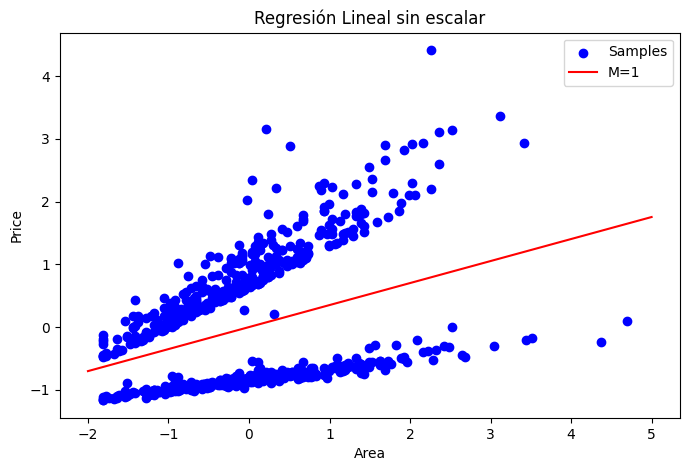

In [569]:
plt.figure(figsize=(8,5))
plt.scatter(Xarea, Y, marker='o', color='blue', label='Samples',)
p=np.linspace(-2, 5, 100)
plt.plot(p, p*0.350676, color='red', label='M=1')
plt.legend()
plt.title("Regresión Lineal sin escalar")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()




MSE:  16376.885093474719
MAE:  88.44962421439486
RMSE:  127.97220437843023


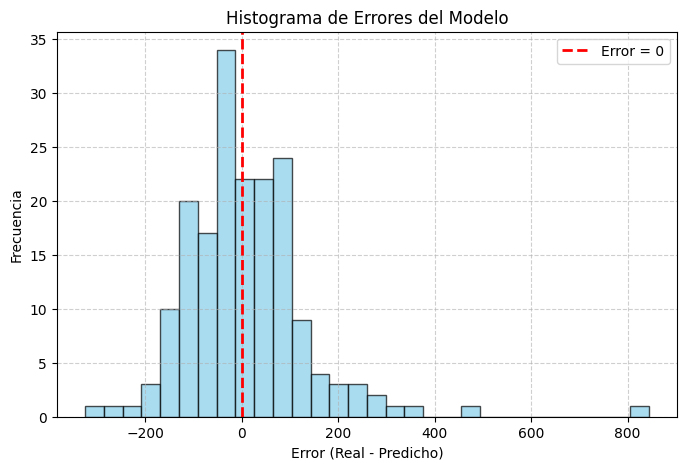

In [594]:
val_x=validation_Normalized.drop(columns=["price"])
val_y=validation_Normalized["price"].to_numpy()

y_validation_pred = modelCompleto.predictPseudoInversa(val_x)

y_validation_pred = y_validation_pred * std["price"] + mean["price"]
val_y = val_y * std["price"] + mean["price"]


errors(val_y,y_validation_pred)

plot_error_histogram(val_y,y_validation_pred)


In [571]:
dfAmanda=pd.read_csv("data/raw/vivienda_Amanda.csv")

dfAmanda.loc[dfAmanda["area_units"] == "sqft", "area"] = 0.092903 * dfAmanda["area"]

dfAmanda=dfAmanda.drop(columns=["area_units"])

dist_zona1 = np.sqrt((dfAmanda["lat"] - lat1)**2 + (dfAmanda["lon"] - lon1)**2)
dist_zona2 = np.sqrt((dfAmanda["lat"] - lat2)**2 + (dfAmanda["lon"] - lon2)**2)



dfAmanda["zona"] = np.where(dist_zona1 < dist_zona2, "Zona 1", "Zona 2")

dfAmanda = one_hot_encoding(dfAmanda, columns=["zona"])

if "zona_Zona 1" not in dfAmanda.columns:
    dfAmanda["zona_Zona 1"] = 0
if "zona_Zona 2" not in dfAmanda.columns:
    dfAmanda["zona_Zona 2"] = 0



dfAmanda=dfAmanda.drop(columns=["lat","lon"])

dfAmanda.to_csv("data/proccesed/vivienda_amanda_proccesed.csv", index=False)

num_cols = dfAmanda.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop(["is_house","has_pool","rooms","zona_Zona 1", "zona_Zona 2"]) #ya son valores binarios

dfAmanda[num_cols] = (dfAmanda[num_cols] - mean[num_cols]) / std[num_cols]



In [573]:
dfAmanda.head()


,area,is_house,has_pool,age,rooms,zona_Zona 2,zona_Zona 1
0,0.303936,0,0,0.157744,3,1,0


Vamos a utilizar todas las features para predecir el precio de la casa de amanda

In [574]:
X_amanda=df_proccesed.copy()
train_Amanda, validation_Amanda= divideDataFrame(X_amanda, 0.8)
train_Amanda,validation_Amanda,mean_Amanda,std_amanda,num_cols = normalizeDataFrame(train_Amanda, validation_Amanda,categoric_Features)

X_amanda=train_Amanda.drop(columns=["price","is_house","has_pool","rooms","age"])
y_amanda=train_Amanda["price"].to_numpy()

modelAmanda=LinearRegression(X_amanda,y_amanda)
modelAmanda.pseudoInversaTraining()
modelAmanda.visualizePseudoInversaCoef()


Coeficientes del modelo (Pseudoinversa):
    Feature   Grado 0   Grado 1
       Bias  0.011198         -
       area         -  0.436126
zona_Zona 2         -  0.869465
zona_Zona 1         - -0.858267


In [ ]:
predict_Amanda=dfAmanda.drop(columns=["is_house","has_pool","rooms","age"])

yPred=modelAmanda.predictPseudoInversa(predict_Amanda)
yPred=(yPred*std_amanda["price"])+mean_Amanda["price"]

print("La predicción de la casa de Amanda es: ",yPred)

       area  zona_Zona 2  zona_Zona 1
0  0.303936            1            0
La predicción de la casa de Amanda es:  [817.84968981]


In [576]:
m2 = df_proccesed["price"] / df_proccesed["area"]  
precio_m2_promedio = m2.mean() 
print(f"El valor promedio por metro cuadrado es: {precio_m2_promedio}")

El valor promedio por metro cuadrado es: 4.987705971319363


Para ver como afecta al precio construir una pileta, estimaremos dos casas, las cuales tienen las mismas caracteristicas excepto la pileta.


In [577]:
casa_sin_pileta = df_proccesed.mean().to_frame().T  
casa_con_pileta = casa_sin_pileta.copy()

casa_sin_pileta["has_pool"] = 0
casa_con_pileta["has_pool"] = 1


casa_sin_pileta[num_cols] = ((casa_sin_pileta[num_cols] - mean[num_cols]) / std[num_cols])
casa_con_pileta[num_cols] = ((casa_con_pileta[num_cols] - mean)[num_cols] / std[num_cols])

casa_sin_pileta = casa_sin_pileta.drop(columns=["price"])
casa_con_pileta = casa_con_pileta.drop(columns=["price"])

precio_sin_pileta = modelCompleto.predictPseudoInversa(casa_sin_pileta)
precio_con_pileta = modelCompleto.predictPseudoInversa(casa_con_pileta)

precio_sin_pileta = precio_sin_pileta * std["price"] + mean["price"]
precio_con_pileta = precio_con_pileta * std["price"] + mean["price"]

diferencia_precio = precio_con_pileta - precio_sin_pileta

print(f"La diferencia de precio por agregar una pileta es: {(diferencia_precio)}")


La diferencia de precio por agregar una pileta es: [46.84435719]


dado que los coeficientes son lineales y la feature "has_pool" es categorica, es decir que solo toma valores de 0 o 1, agregar una pileta agrega un valor de 46.84

EJERCICIO 4

In [578]:
df_new_features = df_proccesed.copy()

df_new_features["density_rooms"] = df_new_features["rooms"] / df_new_features["area"]
df_new_features["area per room"]=df_new_features["area"]/df_new_features["rooms"]
df_new_features["log_area"] = np.log(df_new_features["area"] + 1)
df_new_features["log_age"] = np.log(df_new_features["age"] + 1)


df_new_features.head()



,area,is_house,has_pool,age,price,rooms,zona_Zona 2,zona_Zona 1,density_rooms,area per room,log_area,log_age
0,58.993405,1,0,18.0,546.0,2.0,1,0,0.033902,29.496703,4.094235,2.944439
1,102.007494,0,0,9.0,759.0,3.0,1,0,0.029410,34.002498,4.634802,2.302585
2,61.966301,0,0,7.0,464.0,2.0,1,0,0.032276,30.983151,4.142600,2.079442
3,127.000000,1,1,16.0,251.0,4.0,0,1,0.031496,31.750000,4.852030,2.833213
4,128.020334,0,0,8.0,963.0,4.0,1,0,0.031245,32.005083,4.859970,2.197225


In [579]:
train, validation= divideDataFrame(df_new_features, 0.8)
train_Extended_Normalized,validation_Extended_Normalized,mean_extended,std_extended ,numeric_cols= normalizeDataFrame(train, validation,categoric_Features)

x_Extended=train_Extended_Normalized.drop(columns=["price"])

y_Extended=train_Extended_Normalized["price"].to_numpy()

modelExtended=LinearRegression(x_Extended,y_Extended)
modelExtended.pseudoInversaTraining()
modelExtended.visualizePseudoInversaCoef()




Coeficientes del modelo (Pseudoinversa):
      Feature   Grado 0   Grado 1
         Bias -0.068327         -
         area         - -0.106259
     is_house         -  0.234778
     has_pool         -  0.141166
          age         - -0.013182
        rooms         -   0.40691
  zona_Zona 2         -  0.885227
  zona_Zona 1         - -0.953554
density_rooms         - -0.071693
area per room         -   0.10607
     log_area         -  0.164924
      log_age         - -0.025886


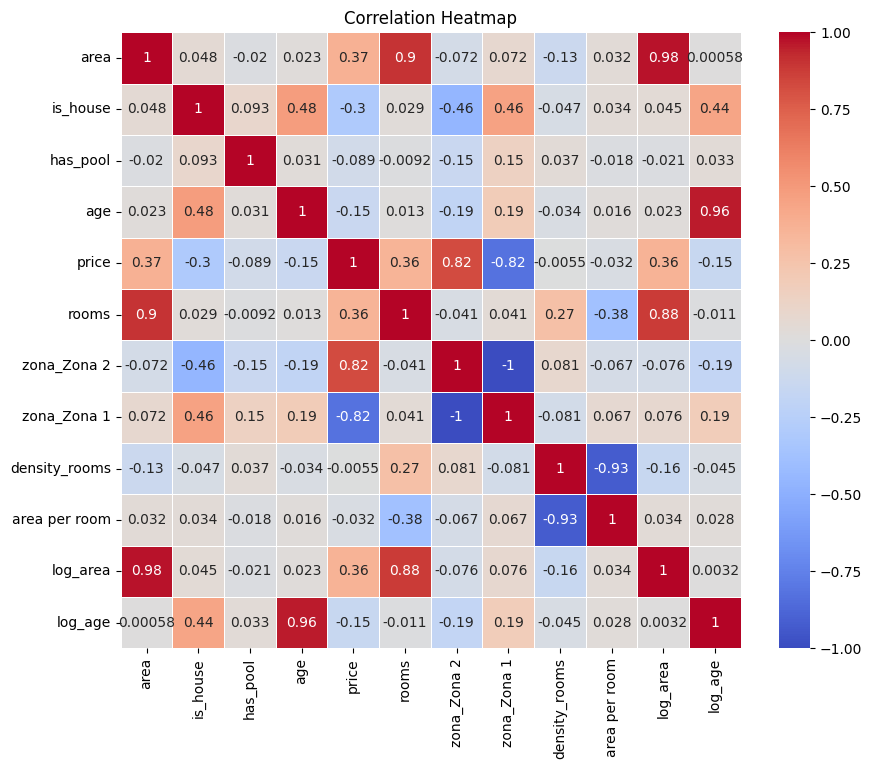

In [580]:

plt.figure(figsize=(10, 8))  
sns.heatmap(df_new_features.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

MSE:  16668.924166099318
MAE:  89.8230302715999
RMSE:  129.10818783523885


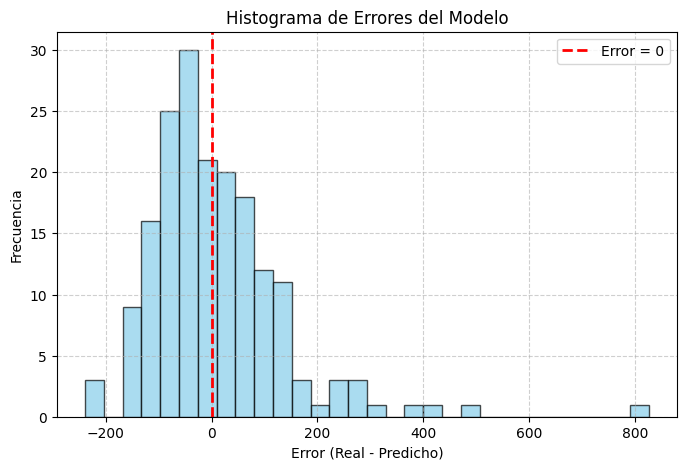

In [597]:

val_Extend_x=validation_Extended_Normalized.drop(columns=["price"])
val_Extended_y=validation_Extended_Normalized["price"].to_numpy()

y_validation_Extended_pred = modelExtended.predictPseudoInversa(val_Extend_x)

y_validation_Extended_pred = y_validation_Extended_pred * std_extended["price"] + mean_extended["price"]
val_Extended_y = (val_Extended_y * std_extended["price"]) + mean_extended["price"]



errors(val_Extended_y,y_validation_Extended_pred)
plot_error_histogram(val_Extended_y,y_validation_Extended_pred)



In [605]:
np.random.seed(42)
XExtremo = df_new_features.copy()

names = XExtremo.columns.to_list()
names.remove("price")
m = len(names)

categoric_extreme_Features = categoric_Features.copy()

for i in range(300):
    potencia = np.random.randint(1, 15)
    feature_name = names[np.random.randint(0, m)]  

    new_feature_name = f"{feature_name} {i}"  
    XExtremo[new_feature_name] = XExtremo[feature_name] ** potencia  

    if feature_name in categoric_extreme_Features:
        categoric_extreme_Features.append(new_feature_name)

train, validation = divideDataFrame(XExtremo, 0.8)

train_Extreme_Normalized, validation_Extreme_Normalized, mean_Extreme, std_Extreme, numeric_cols = normalizeDataFrame(
    train, validation, categoric_extreme_Features
)



/var/folders/cb/dbp_mbjn4r9_2hhc24flvgmw0000gn/T/ipykernel_7433/2990089611.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  XExtremo[new_feature_name] = XExtremo[feature_name] ** potencia
/var/folders/cb/dbp_mbjn4r9_2hhc24flvgmw0000gn/T/ipykernel_7433/2990089611.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  XExtremo[new_feature_name] = XExtremo[feature_name] ** potencia
/var/folders/cb/dbp_mbjn4r9_2hhc24flvgmw0000gn/T/ipykernel_7433/2990089611.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually

In [606]:
XExtremo=train_Extreme_Normalized.drop(columns=["price"])
yExtremo=train_Extreme_Normalized["price"].to_numpy()

modeloExtremo=LinearRegression(XExtremo,yExtremo)
modeloExtremo.pseudoInversaTraining()
val_Extreme_x=validation_Extreme_Normalized.drop(columns=["price"])
val_Extreme_y=validation_Extreme_Normalized["price"].to_numpy()

y_validation_Extreme_pred = modeloExtremo.predictPseudoInversa(val_Extreme_x)

y_validation_Extreme_pred = y_validation_Extreme_pred * std_Extreme["price"] + mean_Extreme["price"]
val_Extreme_y = (val_Extreme_y * std_Extreme["price"]) + mean_Extreme["price"]

print("Error de validación")
errors(val_Extreme_y,y_validation_Extreme_pred)

yTrain=modeloExtremo.predictPseudoInversa(XExtremo)
yTrain = yTrain * std_Extreme["price"] + mean_Extreme["price"]
yExtremo = yExtremo * std_Extreme["price"] + mean_Extreme["price"]

print("Error de entrenamiento")
errors(yExtremo,yTrain)

Error de validación
MSE:  858019.6804546973
MAE:  164.68556750102746
RMSE:  926.2935174417973
Error de entrenamiento
MSE:  12871.568343833807
MAE:  81.79123994656243
RMSE:  113.45293448753895


Es posible observar como al agregar mas features, el modelo se ajusta mejor a los datos de entrenamiento, logrando una mejoria en su error, sin embargo al analizar los errores de validacion, este aumento considerablemente. Esto que esta ocurriendo es un claro ejemplo de overfitting

EJERCICIO 5

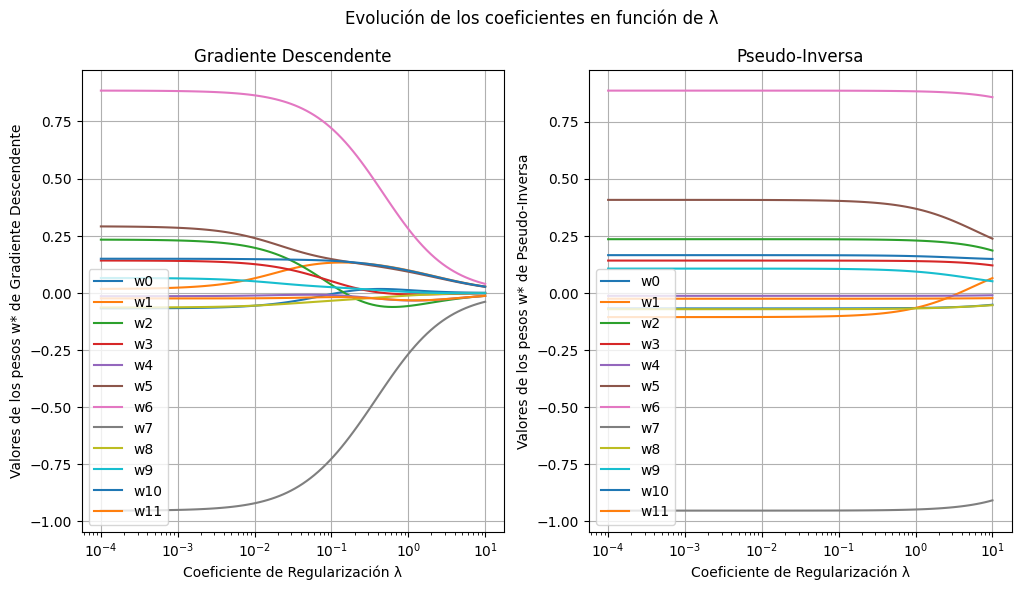

In [607]:
lambda_values=np.logspace(-4, 1, 100)
coeficientesGd = []
coeficientesPI = []

for lambda_reg in lambda_values:
    modelExtended.gradientDescentTraining(L2=lambda_reg)
    modelExtended.pseudoInversaTraining(L2=lambda_reg)

    coeficientesGd.append(modelExtended.getCoefGradientDescent())
    coeficientesPI.append(modelExtended.getCoefPseudoInversa())

coeficientesGd = np.array(coeficientesGd)
coeficientesPI = np.array(coeficientesPI)

fig, axes = plt.subplots(1,2, figsize=(12, 6))  
fig.suptitle("Evolución de los coeficientes en función de λ")

# Primer gráfico
for i in range(coeficientesGd.shape[1]):
    axes[0].plot(lambda_values, coeficientesGd[:, i], label=f"w{i}")

axes[0].set_xscale("log")
axes[0].set_xlabel("Coeficiente de Regularización λ")
axes[0].set_ylabel("Valores de los pesos w* de Gradiente Descendente")
axes[0].set_title("Gradiente Descendente")
axes[0].legend(loc="lower left")
axes[0].grid(True)

# Segundo gráfico
for i in range(coeficientesPI.shape[1]):
    axes[1].plot(lambda_values, coeficientesPI[:, i], label=f"w{i}")

axes[1].set_xscale("log")
axes[1].set_xlabel("Coeficiente de Regularización λ")
axes[1].set_ylabel("Valores de los pesos w* de Pseudo-Inversa")
axes[1].set_title("Pseudo-Inversa")
axes[1].legend(loc="lower left")
axes[1].grid(True)


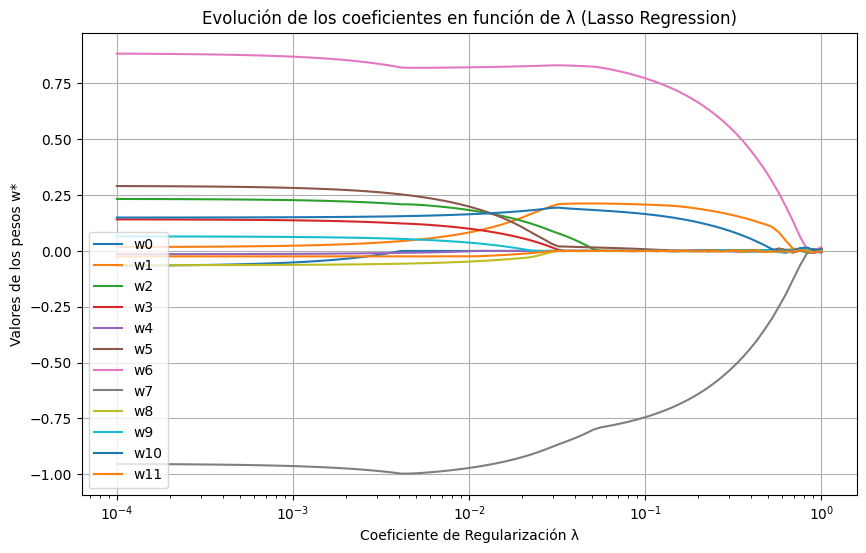

In [608]:
lambda_values = np.logspace(-4, 0, 100)
coeficientes = []

for lambda_reg in lambda_values:
    modelExtended.gradientDescentTraining( L1=lambda_reg)
    coeficientes.append(modelExtended.getCoefGradientDescent())

coeficientes = np.array(coeficientes)

plt.figure(figsize=(10, 6))
for i in range(coeficientes.shape[1]):
    plt.plot(lambda_values, coeficientes[:, i], label=f"w{i}")

plt.xscale("log")  
plt.xlabel("Coeficiente de Regularización λ")
plt.ylabel("Valores de los pesos w*")
plt.title("Evolución de los coeficientes en función de λ (Lasso Regression)")
plt.legend()
plt.grid(True)
plt.show()


Es posible apreciar como Ridge regression(L2) reduce los coeficientes acercandolos a 0 pero nunca anulandolos, mientras que Lasso regression(L1) puede anular los coeficientes.

In [613]:
train, validation= divideDataFrame(df_new_features, 0.8)
train_Extended_Normalized,validation_Extended_Normalized,mean_extended,std_extended ,numeric_cols= normalizeDataFrame(train, validation,categoric_Features)

x_Extended=train_Extended_Normalized.drop(columns=["price"])

y_Extended=train_Extended_Normalized["price"].to_numpy()

modelExtended=LinearRegression(x_Extended,y_Extended)

Utilizando L2=0.05 entrenamos mediante gradiente descendente para ver como afecta la regularizacion. El parametro se eligio analizando cuando ya se notaba un cambio en los coeficientes

In [614]:
modelExtended.pseudoInversaTraining(L2=0.05)
modelExtended.visualizePseudoInversaCoef()



Coeficientes del modelo (Pseudoinversa):
      Feature   Grado 0   Grado 1
         Bias -0.068231         -
         area         - -0.103932
     is_house         -  0.234481
     has_pool         -  0.141051
          age         - -0.013181
        rooms         -  0.404676
  zona_Zona 2         -  0.885072
  zona_Zona 1         - -0.953303
density_rooms         - -0.071508
area per room         -  0.105308
     log_area         -  0.164656
      log_age         - -0.025856


In [616]:
val_Extended_x=validation_Extended_Normalized.drop(columns=["price"])
val_Extended_y=validation_Extended_Normalized["price"].to_numpy()

y_validation_Extended_pred = modelExtended.predictPseudoInversa(val_Extended_x)

val_Extended_y = val_Extended_y * std_extended["price"] + mean_extended["price"]
y_validation_Extended_pred = y_validation_Extended_pred * std_extended["price"] + mean_extended["price"]

print("Error de validación con regularización L2=0.05:")
errors(val_Extended_y,y_validation_Extended_pred)

x= train_Extended_Normalized.drop(columns=["price"])
Ytrain=train_Extended_Normalized["price"].to_numpy()

y_pred=modelExtended.predictPseudoInversa(x)
y_pred = y_pred * std_extended["price"] + mean_extended["price"]
Y=Ytrain * std_extended["price"] + mean_extended["price"]

print("Error de entrenamiento con regularización L2=0.05:")
errors(Y,y_pred)


Error de validación con regularización L2=0.05:
MSE:  16668.924166099318
MAE:  89.8230302715999
RMSE:  129.10818783523885
Error de entrenamiento con regularización L2=0.05:
MSE:  14467.414440541337
MAE:  86.98672288165463
RMSE:  120.28056551472203


la regularizacion L2 evita el sobreajuste de los coeficientes a los datos de entrenamiento, haciendo que el modelo pueda generalizar bien las nuevas entradas. A diferencia de L1 ,L2 conserva todas las variables, reduciendo sus valores raramente hasta 0, generando que todas las variables terminen aportando algun tipo de dato a la prediccion.

Mejor λ encontrado: 0.009545484566618348
ECM mínimo en validación: 127.71723818948551


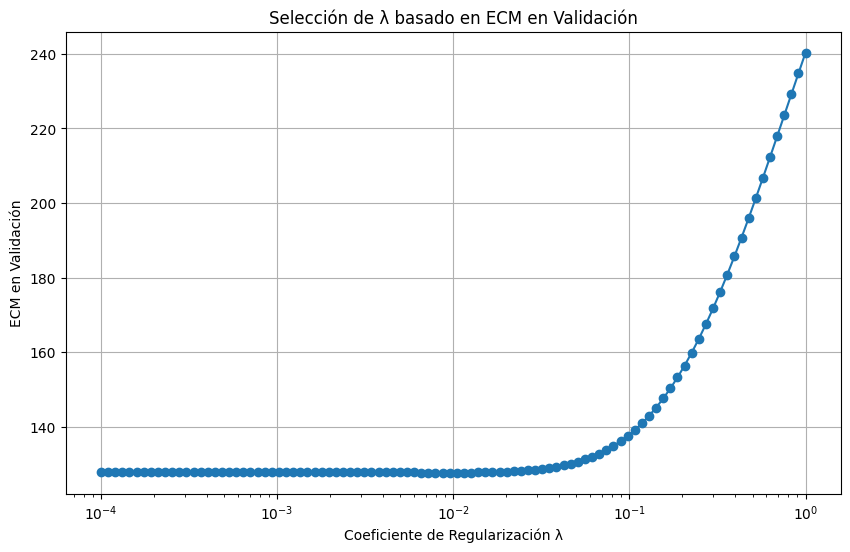

In [ ]:

ecm_values = []
for lambda_reg in lambda_values:

    modelCompleto.gradientDescentTraining(L2=lambda_reg)

    y_validation_pred = modelCompleto.predictGradientDescent(val_x)

    y_validation_pred = y_validation_pred * std["price"] + mean["price"]

    error = rmse(y_validation_pred, val_y)
    ecm_values.append(error)

ecm_values = np.array(ecm_values)

best_lambda = lambda_values[np.argmin(ecm_values)]
best_ecm = np.min(ecm_values)

print(f"Mejor λ encontrado: {best_lambda}")
print(f"ECM mínimo en validación: {best_ecm}")

plt.figure(figsize=(10, 6))
plt.plot(lambda_values, ecm_values, marker='o', linestyle='-')
plt.xscale("log")  
plt.xlabel("Coeficiente de Regularización λ")
plt.ylabel("ECM en Validación")
plt.title("Selección de λ basado en ECM en Validación")
plt.grid(True)
plt.show()



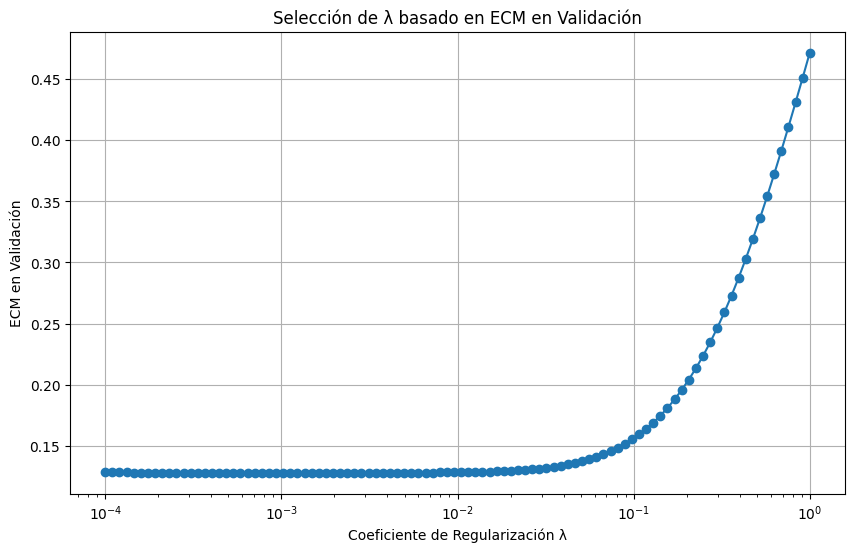

In [ ]:
data_completa = pd.concat([train_Extended_Normalized, validation_Extended_Normalized], axis=0)

data_completa = data_completa.reset_index(drop=True)

cross_X = data_completa.drop(columns=["price"])
cross_Y = data_completa["price"].to_numpy()

ecmVAlues=cross_validation_mse(modelExtended,cross_X,cross_Y,lambda_values)

plt.figure(figsize=(10, 6))
plt.plot(lambda_values, ecmVAlues, marker='o', linestyle='-')
plt.xscale("log")  # Escala logarítmica para λ
plt.xlabel("Coeficiente de Regularización λ")
plt.ylabel("ECM en Validación")
plt.title("Selección de λ basado en ECM en Validación")
plt.grid(True)
plt.show()




EJERCICIO 6

Para implementar en la produccion eligiria el modelo el cual tiene todas las caracteristicas originales, ya que vimos como agregar nuevas features no genero mucho cambio, lo que nos dio a entender que las nuevas caracteristicas obtenidas a partir de las originales estaban muy relacionadas y no nos aportaban ninguna informacion nueva.

In [591]:
DF_test=pd.read_csv("data/raw/casas_test.csv")

DF_test.loc[DF_test["area_units"] == "sqft", "area"] = 0.092903 * DF_test["area"]

DF_test=DF_test.drop(columns=["area_units"])

DF_test = fillNaNs(DF_test)

lat1, lon1 = -40, -50  
lat2, lon2 = 40, -70  

dist_zona1 = np.sqrt((DF_test["lat"] - lat1)**2 + (DF_test["lon"] - lon1)**2)
dist_zona2 = np.sqrt((DF_test["lat"] - lat2)**2 + (DF_test["lon"] - lon2)**2)

DF_test["zona"] = np.where(dist_zona1 < dist_zona2, "Zona 1", "Zona 2")

DF_test = one_hot_encoding(DF_test, columns=["zona"])

DF_test=DF_test.drop(columns=["lat","lon"])

DF_test.to_csv("data/proccesed/casas_test_proccesed.csv", index=False)


In [592]:
test=pd.read_csv("data/proccesed/casas_test_proccesed.csv")
test[num_cols] = (test[num_cols] - mean[num_cols]) / std[num_cols]

x_Test=test.drop(columns=["price"])
y_Test=test["price"].to_numpy()

nuevo_orden = ["area", "is_house", "has_pool", "age","rooms", "zona_Zona 2", "zona_Zona 1"]
x_Test = x_Test[nuevo_orden]

y_pred=modelCompleto.predictPseudoInversa(x_Test)
y_pred = y_pred * std["price"] + mean["price"]
y_Test=y_Test * std["price"] + mean["price"]

errors(y_Test,y_pred)




MSE:  12499.347538971082
MAE:  85.54249249863341
RMSE:  111.80048094248558
